# Dodgers Quantitative Analysis Summer Analyst - Take Home Assessment

## Objective
Build and evaluate a model that predicts the probability that a pitch will result in a strike.

## Instructions
- Complete all sections marked with `# TODO`
- Expected completion time: ~5 hours
- Submit your completed notebook with all cells executed
- You may use AI tools, but any code you generate is fair game for discussion in an interview
- Any code after Part 1 can be deleted and replaced. This code is meant to help but you do not need to work within these guidelines.

## Evaluation Criteria
- Feature engineering and selection
- Model choice and implementation
- Evaluation methodology
- Visualization quality
- Discussion of improvements

## Part 1: Data Loading and Preparation

In [2]:
# Import required libraries
import numpy as np
from pybaseball import statcast
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load 2024 MLB pitch-level data
# Note: This may take several minutes depending on your connection

# Loading data from April through July 2024
start_date = '2024-04-01'
end_date = '2024-07-31'
##Do not add or subtract columns from the list below
cols = ['batter','pitcher','stand','p_throws','sz_top','sz_bot', # player information
        'balls','strikes','inning', # pitch context
        'release_speed','release_pos_x','release_pos_z','pfx_x','pfx_z','plate_x','plate_z', #pitch measurements
        'release_extension','arm_angle', # pitch measurements
        'description']


# Documentation of features available at https://baseballsavant.mlb.com/csv-docs
data = statcast(start_dt=start_date, end_dt=end_date)[cols]

print(f"Loaded {len(data):,} pitches")
print(f"Shape: {data.shape}")

This is a large query, it may take a moment to complete


100%|██████████| 122/122 [02:38<00:00,  1.30s/it]


Loaded 459,016 pitches
Shape: (459016, 19)


## Part 2: Target Variable Construction

### Data Cleaing and Analysis

In [4]:
print("Data Shape: ", data.shape)
# Display the first 15 rows of data
data[cols].head(15)

Data Shape:  (459016, 19)


,batter,pitcher,stand,p_throws,sz_top,sz_bot,balls,strikes,inning,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,plate_x,plate_z,release_extension,arm_angle,description
3207,656180,657044,R,R,3.4,1.63,1,0,9,90.6,-3.65,3.68,-1.04,-0.83,-0.43,2.01,6.9,-8.5,hit_into_play
3351,656180,657044,R,R,3.33,1.63,0,0,9,90.2,-3.71,3.61,-1.15,-0.57,-1.28,1.72,6.8,-8.3,ball
3469,671277,657044,L,R,3.51,1.73,1,0,9,91.7,-3.76,3.68,-1.31,-0.44,1.12,1.39,7.1,-10.2,ball
3587,671277,657044,L,R,3.58,1.8,0,0,9,91.7,-3.59,3.7,-1.19,-0.4,1.71,1.61,7.0,-9.0,ball
3693,623912,657044,R,R,3.25,1.45,1,2,9,92.0,-3.62,3.71,-1.32,-0.57,0.95,1.65,7.0,-8.8,foul_tip
3815,623912,657044,R,R,3.31,1.51,0,2,9,93.3,-3.6,3.75,-1.42,-0.55,0.74,0.53,7.0,-7.6,blocked_ball
3927,623912,657044,R,R,3.25,1.45,0,1,9,91.9,-3.63,3.82,-1.26,-0.55,0.28,1.01,6.9,-6.3,swinging_strike
4043,623912,657044,R,R,3.25,1.45,0,0,9,90.1,-3.76,3.8,-1.09,-0.4,0.46,2.21,6.8,-7.1,foul
2012,695578,623149,L,R,4.01,1.85,3,2,9,93.4,-3.57,4.34,-0.78,1.25,1.22,3.66,6.4,15.6,ball
2067,695578,623149,L,R,3.88,1.83,3,1,9,84.5,-3.65,4.51,0.62,0.75,-0.16,2.86,6.4,21.4,called_strike


In [5]:
data.info()
data.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 459016 entries, 3207 to 4053
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   batter             459016 non-null  Int64  
 1   pitcher            459016 non-null  Int64  
 2   stand              459016 non-null  object 
 3   p_throws           459016 non-null  object 
 4   sz_top             458767 non-null  Float64
 5   sz_bot             458767 non-null  Float64
 6   balls              459016 non-null  Int64  
 7   strikes            459016 non-null  Int64  
 8   inning             459016 non-null  Int64  
 9   release_speed      458766 non-null  Float64
 10  release_pos_x      458767 non-null  Float64
 11  release_pos_z      458767 non-null  Float64
 12  pfx_x              458767 non-null  Float64
 13  pfx_z              458767 non-null  Float64
 14  plate_x            458767 non-null  Float64
 15  plate_z            458767 non-null  Float64
 16  releas

,batter,pitcher,stand,p_throws,sz_top,sz_bot,balls,strikes,inning,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,plate_x,plate_z,release_extension,arm_angle,description
count,459016.0,459016.0,459016,459016,458767.0,458767.0,459016.0,459016.0,459016.0,458766.0,458767.0,458767.0,458767.0,458767.0,458767.0,458767.0,458034.0,456974.0,459016
unique,<NA>,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,13
top,<NA>,<NA>,R,R,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,ball
freq,<NA>,<NA>,263722,336253,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,152746
mean,641012.214966,636257.28872,NaN,NaN,3.415736,1.603268,0.873068,0.904459,4.958335,89.104848,-0.825695,5.756692,-0.097839,0.588546,0.059466,2.298957,6.461806,38.07786,NaN
std,50804.126392,53835.324191,NaN,NaN,0.19036,0.111639,0.965373,0.828399,2.596565,5.953145,1.873327,0.535326,0.898742,0.700619,0.838474,0.962953,0.462838,13.155273,NaN
min,444482.0,434378.0,NaN,NaN,2.52,1.0,0.0,0.0,1.0,31.9,-4.73,0.85,-2.95,-2.45,-5.36,-7.65,3.2,-71.2,NaN
25%,621043.0,607200.0,NaN,NaN,3.29,1.53,0.0,0.0,3.0,84.8,-2.13,5.49,-0.87,0.13,-0.5,1.67,6.2,30.6,NaN
50%,663656.0,657006.0,NaN,NaN,3.41,1.6,1.0,1.0,5.0,90.0,-1.51,5.8,-0.15,0.63,0.06,2.31,6.5,39.3,NaN
75%,671732.0,670280.0,NaN,NaN,3.54,1.68,1.0,2.0,7.0,93.9,0.87,6.09,0.62,1.19,0.62,2.94,6.8,46.5,NaN


In [6]:
# Data Analysis Report for Cleaning
import pandas as pd

df = data.copy() # work on a copy so the original stays intact
N = len(df)

# Create a report dictionary to hold the results of each cleaning rule
report = {}

# Core fields required to define the zone + label + handedness
core_cols = ['sz_top','sz_bot','plate_x','plate_z','description','stand','p_throws']
report['missing_core'] = int(df[core_cols].isna().any(axis=1).sum())

# Invalid zone geometry (bottom must be < top and within plausible feet bounds)
bad_zone = ~((df['sz_bot'] >= 1.0) & (df['sz_top'] <= 5.0) & (df['sz_bot'] < df['sz_top']))
report['invalid_zone_geometry'] = int(bad_zone.sum())

# Plate location glitches (values far outside usable range at the plate)
bad_plate_loc = ~((df['plate_x'].between(-2.0, 2.0, inclusive='both')) &
                  (df['plate_z'].between(0.0, 7.0, inclusive='both')))
report['plate_location_outliers'] = int(bad_plate_loc.sum())

# Unreasonable release speeds
bad_speed = ~df['release_speed'].between(35, 105, inclusive='both')
report['release_speed_outliers'] = int(bad_speed.sum())

# How many remain vs removed if we enforce everything above
mask_clean = (~df[core_cols].isna().any(axis=1)) & (~bad_zone) & (~bad_plate_loc) & (~bad_speed)
report['kept_after_all_rules'] = int(mask_clean.sum())
report['removed_total'] = N - report['kept_after_all_rules']
report['kept_pct'] = round(100 * report['kept_after_all_rules'] / N, 2)

pd.Series(report)

,0
missing_core,249.00
invalid_zone_geometry,0.00
plate_location_outliers,12771.00
release_speed_outliers,5.00
kept_after_all_rules,445990.00
removed_total,13026.00
kept_pct,97.16


In [7]:
# Build masks for data cleaning
mask_core = ~data[core_cols].isna().any(axis=1) # Rows missing any core values to define the zone + label + handedness
mask_zone = (data['sz_bot'] >= 1.0) & (data['sz_top'] <= 5.0) & (data['sz_bot'] < data['sz_top'])
mask_plate = data['plate_x'].between(-2.0, 2.0, inclusive='both') & data['plate_z'].between(0.0, 7.0, inclusive='both')
mask_speed = data['release_speed'].between(35, 105, inclusive='both')

# Apply maks to the dataframe
clean_df = data[mask_core & mask_zone & mask_plate & mask_speed].copy()

# Cast categorical colums to text types
for col in ['stand', 'p_throws', 'description']:
    clean_df[col] = clean_df[col].astype('category')

# Reset index of the cleaned dataframe
clean_df.reset_index(drop=True, inplace=True)

print(f"Cleaned dataset shape: {clean_df.shape}")
print("Missing values check:")
print(clean_df.isna().sum())


Cleaned dataset shape: (445990, 19)
Missing values check:
batter                  0
pitcher                 0
stand                   0
p_throws                0
sz_top                  0
sz_bot                  0
balls                   0
strikes                 0
inning                  0
release_speed           0
release_pos_x           0
release_pos_z           0
pfx_x                   0
pfx_z                   0
plate_x                 0
plate_z                 0
release_extension     706
arm_angle            1729
description             0
dtype: int64


In [8]:
# Handle remaining missing values in less significant columns: 'release_extension' and 'arm_angle'

#Create binary indicator columns to record which rows originally had missing values.
for col in ['release_extension', 'arm_angle']:
    clean_df[col + '_was_missing'] = clean_df[col].isna().astype('int8') # 1 if missing, 0 otherwise

# Fill missing values with the column median.
for col in ['release_extension', 'arm_angle']:
    median_value = clean_df[col].median()
    clean_df[col].fillna(median_value, inplace=True)  # replace nulls with median


# Verify
print(clean_df.isna().sum())

batter                           0
pitcher                          0
stand                            0
p_throws                         0
sz_top                           0
sz_bot                           0
balls                            0
strikes                          0
inning                           0
release_speed                    0
release_pos_x                    0
release_pos_z                    0
pfx_x                            0
pfx_z                            0
plate_x                          0
plate_z                          0
release_extension                0
arm_angle                        0
description                      0
release_extension_was_missing    0
arm_angle_was_missing            0
dtype: int64


#### Inspecting Description Column

In [9]:
#Inspect the 'description' column
descriptions = clean_df['description']

# Frequency table (counts + percent)
vc = descriptions.value_counts(dropna=False)
descscription_freq = (
    vc.to_frame('count')
      .assign(pct=(vc / len(clean_df)).round(4))
      .sort_values('count', ascending=False)
)

# Show the table
descscription_freq


,count,pct
description,,
ball,142966,0.3206
foul,82984,0.1861
hit_into_play,80809,0.1812
called_strike,75421,0.1691
swinging_strike,47425,0.1063
blocked_ball,7557,0.0169
foul_tip,4808,0.0108
swinging_strike_blocked,2352,0.0053
foul_bunt,771,0.0017


#### Implementing is_strike label (target variable)

In [10]:
# Rule-based binary label for is_strike

# Strike outcomes
strike_set = {
    'called_strike',
    'swinging_strike',
    'swinging_strike_blocked',
    'foul',            # will be adjusted for 2 strikes below
    'foul_tip',
    'foul_bunt',
    'bunt_foul_tip',
    'missed_bunt',
}

# Ball / no-strike outcomes
ball_set = {
    'ball',
    'blocked_ball',
    'pitchout',
    'hit_by_pitch',
    'hit_into_play',
}

# Check for unexpected categories
# Combine both sets
mapped_set = strike_set.union(ball_set)

# Get the actual unique categories in data
actual_categories = set(clean_df['description'].unique())

# Find any categories not mapped
unmapped = actual_categories - mapped_set
print("Unmapped categories:", unmapped)


# Initialize label to 0 (ball / no strike)
clean_df['is_strike'] = 0

# Assign 1 for strike outcomes
clean_df.loc[clean_df['description'].isin(strike_set), 'is_strike'] = 1

# Special case for fouls with 2 strikes:
# Fouls do not add a strike when there are already 2 strikes in the count.
mask_foul_two_strikes = (clean_df['description'] == 'foul') & (clean_df['strikes'] == 2)
clean_df.loc[mask_foul_two_strikes, 'is_strike'] = 0

# Quick verification: distribution and a small crosstab
vc_strike = clean_df['is_strike'].value_counts(normalize=True)
descscription_freq_strike = (
    vc_strike.to_frame('pct')
)
descscription_freq_strike

Unmapped categories: set()


,pct
is_strike,
0,0.592164
1,0.407836


**Explanation of Target Variable:**
The binary target variable 'is_strike' is defined according to official MLB rules and batter/umpire outcomes.
A pitch is labeled 1 (strike) when it results in a called strike, swinging strike, swinging strike blocked, foul, foul tip, foul bunt, bunt foul tip, or missed bunt.
It is labeled 0 (ball) when it results in a ball, blocked ball, pitchout, hit by pitch, or any hit into play outcome.
Additionally, foul balls with two strikes are set to 0, reflecting the MLB rule that fouls do not produce an additional strike once two strikes are already recorded.
This rule based approach captures the real outcomes of at bat sequences rather than a geometric location, allowing the model to learn how strikes are actually recorded in real game data.

## Part 3: Feature Engineering and Selection

**TODO:**
1. Explore the available features in the dataset
2. Engineer any new features you think would be predictive
3. Select your final feature set. Choose no more than 10 features.

In [11]:
# Strike zone midpoint (helps normalize plate_z)
clean_df['sz_mid'] = (clean_df['sz_top'] + clean_df['sz_bot']) / 2

# 1.(plate_z_offset) Vertical offset from zone center
clean_df['plate_z_offset'] = clean_df['plate_z'] - clean_df['sz_mid']

# 2.(plate_x_abs) Horizontal distance from plate center (absolute value)
clean_df['plate_x_abs'] = clean_df['plate_x'].abs()

# 3.(is_in_zone) Indicator if pitch is inside the geometric strike zone
clean_df['is_in_zone'] = (
    (clean_df['plate_x'].abs() <= 0.83) &
    (clean_df['plate_z'] >= clean_df['sz_bot']) &
    (clean_df['plate_z'] <= clean_df['sz_top'])
).astype(int)

In [12]:
#4.(in_shadow_zone) Margin around strike zone edges (~0.2 ft = ~2.4 inches)
shadow_margin = 0.2

# Horizontal: within shadow_margin of vertical edges
in_shadow_x = (
    (clean_df['plate_x'].abs() > (0.83 - shadow_margin)) &
    (clean_df['plate_x'].abs() <= (0.83 + shadow_margin))
)

# Vertical: within shadow_margin of top/bottom edges
in_shadow_z = (
    ((clean_df['plate_z'] >= (clean_df['sz_bot'] - shadow_margin)) &
     (clean_df['plate_z'] <= (clean_df['sz_bot'] + shadow_margin))) |
    ((clean_df['plate_z'] >= (clean_df['sz_top'] - shadow_margin)) &
     (clean_df['plate_z'] <= (clean_df['sz_top'] + shadow_margin)))
)

# Combine horizontal or vertical border proximity
clean_df['in_shadow_zone'] = (in_shadow_x | in_shadow_z).astype(int)

# 5. Combine balls and strikes into a single count string
# ['0-0', '0-1', '0-2', '1-0', '1-1', '1-2', '2-0', '2-1', '2-2', '3-0', '3-1', '3-2']
clean_df['count_encoded'] = clean_df['balls'].astype(str) + '-' + clean_df['strikes'].astype(str)



In [13]:
feature_columns = [
    # Geometry
    'plate_x_abs', 'plate_z_offset', 'is_in_zone', 'in_shadow_zone',

    # Pitch traits
    'release_speed', 'pfx_x', 'pfx_z',

    # Balls/Strike Count
    'count_encoded',

    # Handedness
    'stand', 'p_throws'
]



**Feature Selection Rationale:**

The final features combine geometric, contextual, and physical predictors of strike outcomes.
'plate_x_abs', 'plate_z_offset', 'is_in_zone', and 'in_shadow_zone' describe a pitch’s position relative to the zone, including ambiguous border regions where umpire calls are inconsistent.
'release_speed', 'pfx_x', and 'pfx_z' represent pitch movement and velocity, influencing batter perception and umpire judgment.
'count_encoded' captures the interaction between balls and strikes, reflecting how strike zone enforcement varies by count. 'stand' and 'p_throws' encode batter and pitcher handedness matchups.

## Part 4: Train-Test Split

Split the data into training (80%) and test (20%) sets.

In [14]:
# Train-Test split
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
x = clean_df.drop(columns=['is_strike'])  # all predictors
y = clean_df['is_strike']                 # target variable

# Split into train (80%) and test (20%)
# Use stratify=y to preserve class balance across sets
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,         # 20% for testing
    random_state=42,       # reproducibility
    stratify=y             # ensures train and test have the same strike/ball proportions as full dataset
)

# Display shapes to confirm split
print("Train set:", x_train.shape, y_train.shape)
print("Test set:", x_test.shape, y_test.shape)

# Check on class balance
print("Train label distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("Test label distribution:")
print(y_test.value_counts(normalize=True).round(3))


Train set: (356792, 27) (356792,)
Test set: (89198, 27) (89198,)
Train label distribution:
is_strike
0    0.592
1    0.408
Name: proportion, dtype: float64
Test label distribution:
is_strike
0    0.592
1    0.408
Name: proportion, dtype: float64


In [15]:
#Preprocessing data for training
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    'plate_x_abs', 'plate_z_offset', 'is_in_zone', 'in_shadow_zone',
    'release_speed', 'pfx_x', 'pfx_z'
]

categorical_features = [
    'count_encoded', 'stand', 'p_throws'
]

# Scale numeric features so they have same ranges (mean=0, std=1)
# Helps models converge and allows for equal contribution of features
numeric_transformer = StandardScaler()

# One hot encode categorical features
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

# Apply transformation to each group of respective columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [16]:
# Fit the preprocessor and transform the data
x_train_proc = preprocessor.fit_transform(x_train[feature_columns])
x_test_proc  = preprocessor.transform(x_test[feature_columns])

print("Transformed train shape:", x_train_proc.shape)
print("Transformed test shape:", x_test_proc.shape)


Transformed train shape: (356792, 20)
Transformed test shape: (89198, 20)


## Part 5: Model Training

**TODO:**
1. Choose an appropriate model for this classification task
2. Train your model on the training set
3. Consider hyperparameter tuning if time allows

In [17]:
import xgboost as xgb

# Initialize an XGBoost classifier for binary classification
xgb_model = xgb.XGBClassifier(
    # Basic configuration
    objective='binary:logistic',   # binary output
    eval_metric='logloss',         # evaluation metric to minimize during training
    use_label_encoder=False,       # disables old XGB version label encoder
    random_state=42,
    n_jobs=-1,

    # Hyperparameters controlling learning behavior
    n_estimators=300,              # total number of trees
    learning_rate=0.1,
    max_depth=6,                   # maximum depth of each decision tree
    subsample=0.8,                 # fraction of training samples used per boosting round
    colsample_bytree=0.8,          # fraction of features randomly selected per tree
    reg_lambda=1.0,                # L2 regularization term (reduces overfitting by penalizing large weights)
    reg_alpha=0.0                  # L1 regularization term (encourages sparsity)
)



In [18]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Define the search space for hyperparameters
param_dist = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda': [0.5, 1, 2],
    'reg_alpha': [0, 0.5, 1]
}

# Create a stratified cross-validation splitter
# Ensures that each fold preserves the same strike/ball class ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform randomized search over the defined parameter grid
rs_xgb = RandomizedSearchCV(
    estimator=xgb_model,                   # base XGBoost model
    param_distributions=param_dist,        # parameter ranges to sample from
    n_iter=14,                             # number of random combinations to try
    scoring='f1',                          # optimize for F1 score
    cv=cv,                                 # use 5-fold stratified cross-validation
    verbose=1,                             # print progress
    n_jobs=-1,
    random_state=42
)

# Run randomized search on preprocessed training data
rs_xgb.fit(x_train_proc, y_train)

print("Best parameters:", rs_xgb.best_params_)
print("Best F1 score:", round(rs_xgb.best_score_, 3))


Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best parameters: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best F1 score: 0.705


**Model Selection Rationale:**

I trained an XGBoost model with cross-validation for this classification task. XGBoost is well suited for predicting strikes because it can learn complex, non-linear patterns between variables like pitch location, count, and movement. XGBoost improves on traditional tree models by building trees sequentially in which each tree learns from the mistakes of the previous. This allows the model to capture subtle effects that a single model might miss.

While simpler models such as Logistic Regression could serve as a baseline for linear relationships, they are limited in handling the complex interactions present in this dataset. I also tested a Random Forest model and it provided strong results but struggled with borderline strike cases. XGBoost achieved the best overall balance, improving both recall and F1 score for the strike class.

If given more time, I would further tune parameters like learning_rate, max_depth, and n_estimators, and experiment with additional features such as pitch type, spin rate, and umpire data to help the model account for variation in strike calls.

## Part 6: Model Evaluation

**TODO:**
1. Make predictions
2. Calculate relevant evaluation metrics
3. Interpret the results

In [19]:
# Make predictions on the test set
y_pred_xgb = rs_xgb.best_estimator_.predict(x_test_proc)

In [20]:
# Evaluate Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"Accuracy:  {acc_xgb:.3f}")
print(f"Precision: {prec_xgb:.3f}")
print(f"Recall:    {rec_xgb:.3f}")
print(f"F1 Score:  {f1_xgb:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, digits=3))

Accuracy:  0.758
Precision: 0.698
Recall:    0.716
F1 Score:  0.707

Classification Report:
               precision    recall  f1-score   support

           0      0.801     0.786     0.793     52820
           1      0.698     0.716     0.707     36378

    accuracy                          0.758     89198
   macro avg      0.749     0.751     0.750     89198
weighted avg      0.759     0.758     0.758     89198



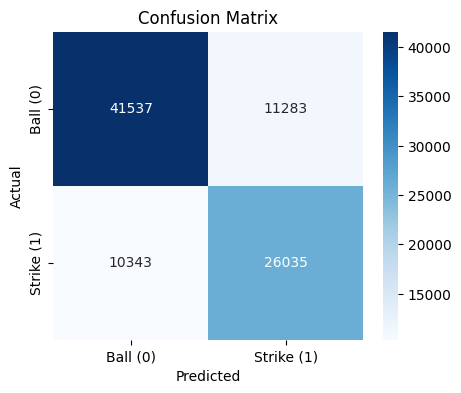

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ball (0)', 'Strike (1)'], yticklabels=['Ball (0)', 'Strike (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### Interpretation
The model achieved an accuracy of 75.8%, correctly predicting approximately three out of four pitches as either strikes or balls.

For the strike class (1):

Precision = 0.70: When the model predicts a strike, it’s correct about 70% of the time.

Recall = 0.72: It correctly identifies 72% of all true strikes.

F1-score = 0.71: Balanced measure accuracy considering balls misclassified as strikes and missed strikes.

For the ball class (0), both precision and recall are slightly higher (0.79–0.80), meaning the model is somewhat better at recognizing balls than strikes.
This pattern is expected because balls occur in more distinct locations (outside the zone), while strikes can fall in borderline areas (“shadow zone”) that are harder to classify.

The confusion matrix shows:

41,537 true negatives (correctly predicted balls)

26,035 true positives (correctly predicted strikes)

11,283 false positives (balls misclassified as strikes)

10,343 false negatives (missed strikes)

Overall, the model demonstrates a strong balance between precision and recall, showing that it can reliably distinguish most strikes from balls. Its small bias toward predicting balls reflects the natural ambiguity of pitches near the zone’s edge.

## Part 7: Visualization

**TODO:** Create a visual representation of an interesting finding from your model

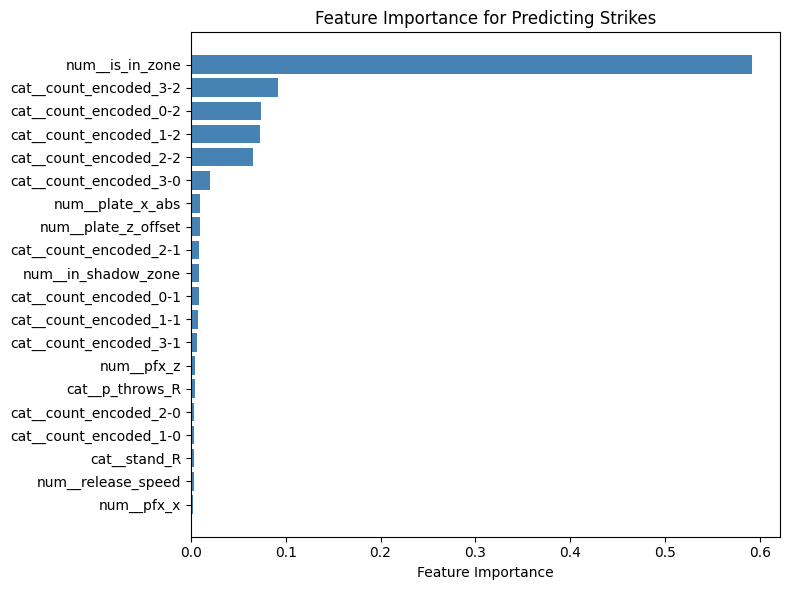

In [22]:
# Get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

# Get importances from the trained Random Forest
importances = rs_xgb.best_estimator_.feature_importances_

# Sort by importance in descending order
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, len(feature_names) * 0.3)) # Adjust figure size based on number of features
plt.barh(range(len(feature_names)), importances[indices][::-1], color='steelblue') # plot bar graph
plt.yticks(range(len(feature_names)), [feature_names[i] for i in indices][::-1])
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Predicting Strikes")
plt.tight_layout()
plt.show()

## Part 8: Discussion and Future Improvements

**TODO:** In under 200 words, discuss:
1. What aspects of the model would you prioritize improving if you had more time?
2. What additional data or features would be most valuable?

---
The XGBoost model achieved an accuracy of 75.8%, showing strong performance in distinguishing strikes from balls. Feature importance revealed that pitch location and count context were by far the most predictive factors. This is consistent with baseball intuition and rules. However, the model struggled with borderline “shadow zone” pitches, where it is expected that umpires are most inconsistent. This suggests that while spatial and contextual features capture much of the strike zone behavior, human/umpire factors remain underrepresented in the model.

My next steps would prioritize improving the model’s recall for strikes through more extensive hyperparameter tuning and optimizing the strike threshold. This could help balance precision and recall, particularly for ambiguous pitches. Additionally, incorporating new features such as the pitch type, spin rate, umpire behavior/tendencies, or previous pitch results could improve predictive depth and better repsent human factors.

Overall, the model provides a strong foundation for strike prediction and provides clear interpretability through feature importance. Further development could help capture the more nuanced and human-based elements of pitch calling.

---

## Submission Checklist

Before submitting, ensure:
- [ ] All cells execute without errors
- [ ] Target variable is clearly defined and justified
- [ ] Features are selected and engineered with rationale
- [ ] Model is trained and evaluated with appropriate metrics
- [ ] Visualization is clear and informative
- [ ] Discussion section is complete (under 200 words)
- [ ] Code is well-commented and readable